# Taller de Diseño de Redes Confiables

Clasificación neuronal para la concesión de crédito sobre el dataset *Home Credit Default Risk* (`application_train.csv`), con foco en **Aprendizaje Justo** (Fair Loss) e **Incertidumbre** de las predicciones.

El notebook parte del esqueleto de lectura y preprocesado y desarrolla sobre él los bloques de Aprendizaje Justo e Incertidumbre. Cada decisión metodológica se documenta y justifica en las celdas de markdown.

## 0. Punto de partida: lectura y preprocesado base

Se reproduce el esqueleto de lectura de datos como base de trabajo. Las celdas siguientes cargan el dataset, seleccionan las variables relevantes y aplican un preprocesado inicial (codificación del género, conversión de la edad e imputación por mediana de las fuentes externas).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 0.1. Carga completa del dataset

In [2]:
df = pd.read_csv('application_train.csv')
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 0.2. Carga de las columnas relevantes y preprocesado inicial

In [3]:

def load_home_credit_data(file_path):
    cols = [
        'TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
    ]

    df = pd.read_csv(file_path, usecols=cols)

    # Preprocesado rápido
    # 1. Convertir género a numérico (Variable Sensible)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0)

    # 2. Edad a años positivos
    df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

    # 3. Tratar valores nulos en fuentes externas (clave para la incertidumbre)
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[col] = df[col].fillna(df[col].median())

    # Separar variables
    X = df.drop(columns=['TARGET'])
    y = df['TARGET']
    s = df['CODE_GENDER'] # Guardamos la variable sensible aparte para la Loss Custom

    # Split
    X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
        X, y, s, test_size=0.2, random_state=42
    )

    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (X_train, y_train, s_train), (X_test, y_test, s_test)



In [4]:
# Uso:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data('application_train.csv')

In [5]:
import numpy as np

# Ensure y_train and s_train are 2D arrays for stacking
y_train_reshaped = y_train.values.reshape(-1, 1)

# Combine X_train, y_train, and s_train into a single matrix
combined_data_train = np.hstack((X_train, y_train_reshaped))

print("Shape of the combined training data matrix:", combined_data_train.shape)
print("First 5 rows of the combined training data matrix:\n", combined_data_train[:5,:])

Shape of the combined training data matrix: (246008, 9)
First 5 rows of the combined training data matrix:
 [[ 0.72106056  0.02430965 -0.11006828 -0.74109349  1.67613559  0.14518024
  -0.81696045  0.27469408  0.        ]
 [-1.38684607 -0.10484026 -0.99617411 -0.2399438  -1.17349864 -1.86232543
  -0.12674396  0.4556939   0.        ]
 [-1.38684607 -0.32009011  0.43826238 -0.13419378  1.64495195  0.0110865
   0.67540116  1.08962181  1.        ]
 [-1.38684607 -0.04138461  0.74512571  0.66621918 -1.22348418 -1.54862838
  -0.46140535 -0.05358255  0.        ]
 [-1.38684607  0.54090928 -0.16366442 -0.40151496 -0.0552442   2.05055166
  -0.36044038  0.0701048   0.        ]]


In [6]:
print(X_train.shape)
print(y_train.shape)
print(s_train.shape)
print(combined_data_train.shape)

(246008, 8)
(246008,)
(246008,)
(246008, 9)


### 0.3. Exploración: matriz de dispersión de las variables escaladas

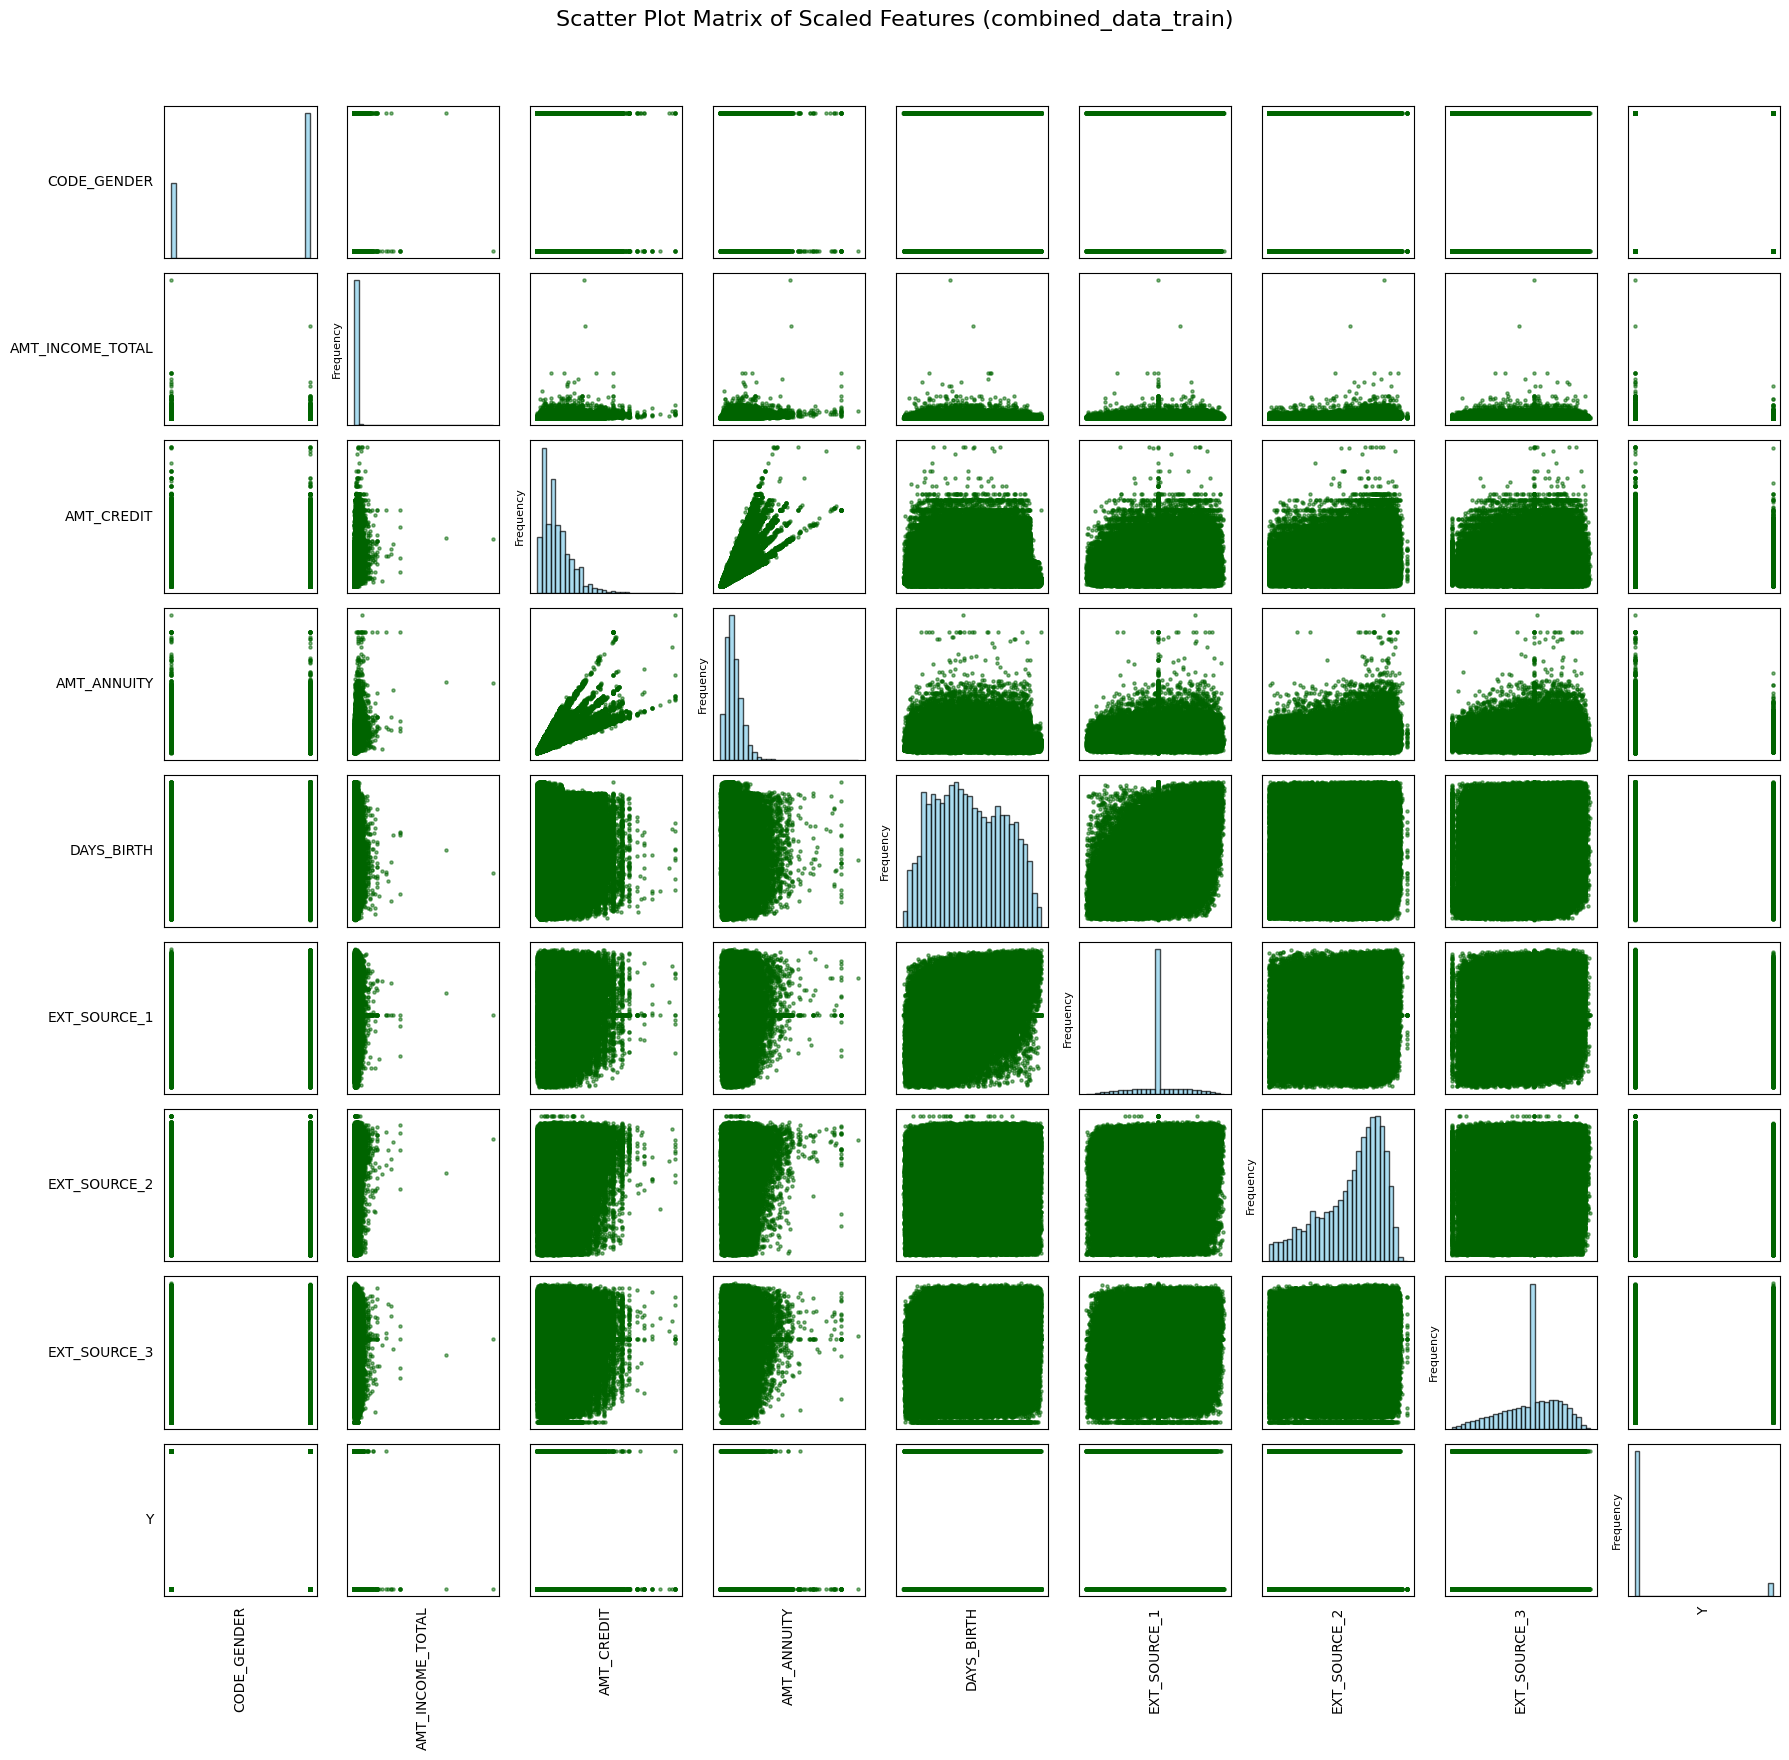

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct column names for better labels, assuming the order from load_home_credit_data function
feature_names = [
    'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3','Y'
]

n_features = combined_data_train.shape[1]
fig, axes = plt.subplots(n_features, n_features, figsize=(18, 18))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # On diagonal, plot histogram
            ax.hist(combined_data_train[:, i], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=8)
        else:
            # Off-diagonal, plot scatter plot
            ax.scatter(combined_data_train[:, j], combined_data_train[:, i], alpha=0.5, s=5, color='darkgreen')
            ax.set_aspect('auto')

        # Set labels for the outer plots only
        if i == n_features - 1: # Bottom row
            ax.set_xlabel(feature_names[j], rotation=90, ha='center', fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0: # Leftmost column
            ax.set_ylabel(feature_names[i], rotation=0, ha='right', va='center', fontsize=10)
        else:
            ax.set_yticks([])

        # Remove ticks for all inner plots
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

plt.suptitle('Scatter Plot Matrix of Scaled Features (combined_data_train)', y=1.005, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 1. Aprendizaje Justo (Fair Loss)

Objetivo: entrenar un clasificador cuyas decisiones no dependan de la variable sensible (género, `CODE_GENDER`), penalizando de forma explícita la dependencia estadística entre la predicción del modelo y dicha variable. Se construye primero el preprocesado y la función de coste customizada; sobre ella se entrenan un **modelo Base** (sin penalización) y un **modelo Fair** (con penalización), que se comparan en test.

### 1.1. Preprocesado refinado

El esqueleto de la Sección 0 es un punto de partida funcional, pero un planteamiento de aprendizaje justo y de cuantificación de incertidumbre exige varios ajustes. Cada uno se justifica a continuación.

**1. Tratamiento de registros anómalos.** La variable sensible presenta 4 registros `XNA` (género no informado) y `AMT_ANNUITY` contiene 12 valores ausentes. Se descartan estas filas (16 de 307.511, un 0,005% del total). Asignar un valor arbitrario a la variable sensible introduciría ruido directamente sobre la magnitud que la penalización de fairness pretende controlar; dado su volumen despreciable, el descarte es preferible.

**2. Flags de missingness *antes* de imputar.** Las fuentes externas presentan ausencias estructurales muy dispares: `EXT_SOURCE_1` está ausente en el 56,4% de los casos, `EXT_SOURCE_3` en el 19,8% y `EXT_SOURCE_2` en el 0,2%. Tras imputar por mediana, un valor real y uno imputado resultan indistinguibles para la red, perdiéndose la información de que el dato fue reconstruido. Se crean tres indicadores binarios (`EXT_SOURCE_k_missing`) que registran esa ausencia original. La distribución del número de fuentes imputadas por individuo —0 en el 35,6%, 1 en el 52,4%, 2 en el 11,9% y 3 en el 0,06%— define grupos de calidad de fuentes que serán el eje del análisis de incertidumbre.

**3. Imputación por mediana.** Se mantiene la imputación por mediana de las fuentes externas por su robustez frente a valores extremos. La información de ausencia queda preservada por los flags del punto anterior.

**4. Dos vistas de las variables de entrada sobre las mismas filas.** Se construyen dos conjuntos de features:
- **Base**: incluye el género como variable de entrada. Sirve de referencia y permite cuantificar la dependencia de partida.
- **Fair**: excluye el género de la entrada; la variable sensible no se proporciona al modelo y se reserva únicamente para la penalización de la loss.

Ambas vistas se derivan del **mismo** particionado, de modo que la comparación Base vs Fair se realiza sobre exactamente los mismos individuos en test.

**5. Particionado estratificado por `TARGET`.** Con una prevalencia de impago del 8%, un split aleatorio simple puede generar particiones con proporciones de clase distintas. La estratificación por `TARGET` mantiene la prevalencia (~8%) en train, validación y test, condición necesaria para que las métricas entre particiones sean comparables. Reparto 64/16/20.

**6. Escalado solo de variables continuas, ajustado solo con train.** El `StandardScaler` se ajusta exclusivamente con la partición de entrenamiento (evita fuga de información hacia validación y test) y se aplica únicamente sobre las variables continuas. Estandarizar variables binarias (género y flags) distorsiona su escala 0/1 sin aportar valor; se mantienen sin transformar.

**7. Sobre el efecto proxy.** Excluir el género de la entrada (vista Fair) no garantiza por sí solo un modelo justo: otras variables (ingresos, anualidad) pueden actuar como proxy y recoger información del género de forma implícita. La penalización de la Fair Loss actúa sobre la dependencia entre la predicción y el género con independencia del canal por el que esta entre. La comparativa Base vs Fair permitirá observar la dependencia residual.

In [8]:
# ---- Preprocesado refinado para Aprendizaje Justo ----
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RUTA = 'application_train.csv'
SEED = 42

EXT_COLS  = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
FLAG_COLS = [f'{c}_missing' for c in EXT_COLS]
CONT_COLS = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH'] + EXT_COLS


def cargar_datos_fair(ruta):
    cols = ['TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
            'AMT_ANNUITY', 'DAYS_BIRTH'] + EXT_COLS
    df = pd.read_csv(ruta, usecols=cols)

    # 1. Género -> numérico (M:0, F:1). Los 4 'XNA' quedan como NaN y se descartan.
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})

    # 2. Edad: de días negativos a años positivos.
    df['DAYS_BIRTH'] = np.abs(df['DAYS_BIRTH']) / 365.0

    # 3. Flags de missingness ANTES de imputar (preservan la info de ausencia).
    for c in EXT_COLS:
        df[f'{c}_missing'] = df[c].isna().astype(int)

    # 4. Descarte de filas con sensible ambiguo (XNA) o AMT_ANNUITY ausente (16 filas).
    df = df.dropna(subset=['CODE_GENDER', 'AMT_ANNUITY']).reset_index(drop=True)
    df['CODE_GENDER'] = df['CODE_GENDER'].astype(int)

    # 5. Imputación por mediana de las fuentes externas.
    for c in EXT_COLS:
        df[c] = df[c].fillna(df[c].median())

    return df


df_fair = cargar_datos_fair(RUTA)

# Objetivo y variable sensible (esta se reserva aparte para la Fair Loss).
y = df_fair['TARGET'].values.astype('float32')
s = df_fair['CODE_GENDER'].values.astype('float32')

# Dos vistas de las features sobre las mismas filas.
feat_base = ['CODE_GENDER'] + CONT_COLS + FLAG_COLS   # incluye género
feat_fair = CONT_COLS + FLAG_COLS                     # excluye género

# Split único estratificado por TARGET (64/16/20).
idx = np.arange(len(df_fair))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y)
idx_tr, idx_va = train_test_split(idx_tr, test_size=0.2, random_state=SEED, stratify=y[idx_tr])

# Escalado: ajustado SOLO con train y SOLO sobre continuas. Binarias passthrough.
scaler = StandardScaler().fit(df_fair.loc[idx_tr, CONT_COLS])

def construir_X(indices, feats):
    bloque = df_fair.loc[indices, feats].copy()
    bloque[CONT_COLS] = scaler.transform(bloque[CONT_COLS])  # solo continuas
    return bloque.values.astype('float32')

# Matrices Base (con género) y Fair (sin género).
X_base_tr, X_base_va, X_base_te = (construir_X(i, feat_base) for i in (idx_tr, idx_va, idx_te))
X_fair_tr, X_fair_va, X_fair_te = (construir_X(i, feat_fair) for i in (idx_tr, idx_va, idx_te))

# Targets y sensible por partición.
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]
s_tr, s_va, s_te = s[idx_tr], s[idx_va], s[idx_te]

# ---- Verificación ----
print('Filas tras limpieza:', len(df_fair))
print('Shape X_base (tr/va/te):', X_base_tr.shape, X_base_va.shape, X_base_te.shape)
print('Shape X_fair (tr/va/te):', X_fair_tr.shape, X_fair_va.shape, X_fair_te.shape)
print('\nFeatures Base:', feat_base)
print('Features Fair:', feat_fair)
print(f'\nPrevalencia TARGET  (tr/va/te): {y_tr.mean():.4f} / {y_va.mean():.4f} / {y_te.mean():.4f}')
print(f'% mujeres (s=1)     (tr/va/te): {s_tr.mean():.4f} / {s_va.mean():.4f} / {s_te.mean():.4f}')
print('Prevalencia flags EXT (train):',
      {c: round(float(df_fair.loc[idx_tr, c].mean()), 4) for c in FLAG_COLS})

Filas tras limpieza: 307495
Shape X_base (tr/va/te): (196796, 11) (49200, 11) (61499, 11)
Shape X_fair (tr/va/te): (196796, 10) (49200, 10) (61499, 10)

Features Base: ['CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']
Features Fair: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Prevalencia TARGET  (tr/va/te): 0.0807 / 0.0807 / 0.0807
% mujeres (s=1)     (tr/va/te): 0.6583 / 0.6576 / 0.6592
Prevalencia flags EXT (train): {'EXT_SOURCE_1_missing': 0.5641, 'EXT_SOURCE_2_missing': 0.0021, 'EXT_SOURCE_3_missing': 0.1985}


### 1.2. Función de coste customizada (Fair Loss)

La función de coste combina dos objetivos en un único término optimizable por descenso de gradiente:

$$\mathcal{L}(\hat{y},\, y,\, s) = \text{BCE}_w(y, \hat{y}) \;+\; \lambda \cdot \rho(\hat{y}, s)^2$$

**Término 1 — error de clasificación.** Entropía cruzada binaria entre la etiqueta real y la probabilidad predicha, ponderada por clase: cada muestra pesa $w_1$ si es impago y $w_0$ en caso contrario, con pesos inversos a la frecuencia (≈11,4× para la clase positiva). La ponderación se incorpora dentro de la loss en lugar de vía `class_weight`, por dos motivos: (i) `class_weight` no es compatible con etiquetas extendidas $[y, s]$ ni con una penalización a nivel de batch; y (ii) al aplicarse de forma idéntica en train y validación, ambas *loss* quedan en la misma escala y las curvas de convergencia resultan directamente comparables.

**Término 2 — penalización por dependencia.** Correlación de Pearson al cuadrado entre la probabilidad predicha y la variable sensible. Es derivable —a diferencia de métricas de fairness como la diferencia de paridad demográfica, no penalizables directamente por gradiente—, está acotada en $[0, 1]$ (0 = independencia lineal) y, al elevarse al cuadrado, penaliza por igual correlación positiva y negativa empujándola hacia cero. Constituye un proxy directo de paridad demográfica: si la decisión es independiente del género, la tasa de concesión se iguala entre grupos.

**Coeficiente $\lambda$.** Regula el equilibrio precisión↔justicia. Con $\lambda=0$ la penalización desaparece y la loss es BCE ponderada pura (modelo Base). Al aumentar $\lambda$ se sacrifica capacidad predictiva a cambio de menor dependencia.

**Etiquetas extendidas.** La función de coste solo recibe `y_true` e `y_pred`. Para disponer de la variable sensible dentro de la loss, se apilan la etiqueta real y el género en un tensor de dos columnas $[y, s]$ que se entrega como `y_true`.

In [9]:
# ---- Función de coste customizada (Fair Loss) ----
import keras
from keras import ops
from sklearn.utils.class_weight import compute_class_weight

# Pesos de clase (inversos a la frecuencia) que entran DENTRO de la loss.
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
W0, W1 = float(cw[0]), float(cw[1])
print('Pesos de clase -> w0:', round(W0, 4), '| w1:', round(W1, 4))


class FairLoss(keras.losses.Loss):
    """BCE ponderada por clase + lambda * Pearson(y_pred, s)^2.
    y_true llega extendido como [y_real, s] (dos columnas)."""

    def __init__(self, lam=1.0, w0=1.0, w1=1.0, name='fair_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lam, self.w0, self.w1 = lam, w0, w1

    def call(self, y_true_ext, y_pred):
        y = ops.cast(y_true_ext[:, 0], 'float32')          # etiqueta real
        s = ops.cast(y_true_ext[:, 1], 'float32')          # variable sensible
        yhat = ops.squeeze(y_pred, axis=-1) if len(y_pred.shape) > 1 else y_pred
        yhat = ops.clip(yhat, 1e-7, 1 - 1e-7)              # estabilidad del log

        # Término 1: BCE ponderada por clase (media ponderada).
        bce = -(y * ops.log(yhat) + (1 - y) * ops.log(1 - yhat))
        w = y * self.w1 + (1 - y) * self.w0
        bce_w = ops.sum(w * bce) / ops.sum(w)

        # Término 2: penalización por dependencia (Pearson^2).
        yhat_c = yhat - ops.mean(yhat)
        s_c = s - ops.mean(s)
        cov = ops.mean(yhat_c * s_c)
        den = ops.sqrt(ops.mean(ops.square(yhat_c)) * ops.mean(ops.square(s_c))) + 1e-7
        penalty = ops.square(cov / den)

        return bce_w + self.lam * penalty


# Etiquetas extendidas [y, s] por partición.
def extender(y_arr, s_arr):
    return np.stack([y_arr, s_arr], axis=1).astype('float32')

y_tr_ext = extender(y_tr, s_tr)
y_va_ext = extender(y_va, s_va)
y_te_ext = extender(y_te, s_te)
print('Shape etiquetas extendidas (train):', y_tr_ext.shape)

/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Diseño de Redes Confiables/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Pesos de clase -> w0: 0.5439 | w1: 6.1932
Shape etiquetas extendidas (train): (196796, 2)


### 1.3. Modelo Base (Fair Loss con λ=0)

Modelo de referencia, entrenado con la Fair Loss en $\lambda=0$ (sin penalización de justicia) y sobre la vista **con género** (`X_base`, 11 variables). Cuantifica el rendimiento y la dependencia de partida sobre los que se medirá el efecto de la penalización.

Arquitectura y entrenamiento:
- **MLP 16 → 8 → 1**, capas ocultas con ReLU (gradiente estable, sin el desvanecimiento propio de la sigmoide en capas internas) y salida sigmoide para producir una probabilidad en $[0, 1]$.
- **Pesos de clase dentro de la loss** para compensar el 8% de positivos.
- **`batch_size` = 128** y **entrenamiento completo de 30 épocas** sin parada temprana, para observar la convergencia.

Se monitoriza la **accuracy** durante el entrenamiento. No obstante, con un desbalanceo del 8% la accuracy es una métrica engañosa —un clasificador que prediga siempre la clase mayoritaria alcanza ~92% sin detectar ningún impago—, por lo que la evaluación final (1.5) se apoya además en AUC-ROC y AUC-PR, independientes del umbral.

In [10]:
# ---- Modelo Base: Fair Loss con lambda=0, vista CON género ----
EPOCHS, BATCH = 30, 128

def construir_mlp(n_inputs, nombre):
    keras.utils.set_random_seed(SEED)
    return keras.Sequential([
        keras.layers.Input(shape=(n_inputs,)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(8,  activation='relu'),
        keras.layers.Dense(1,  activation='sigmoid')
    ], name=nombre)

# La accuracy necesita la etiqueta real, que viaja en la columna 0 del target extendido.
class AccExt(keras.metrics.BinaryAccuracy):
    def update_state(self, y_true_ext, y_pred, sample_weight=None):
        super().update_state(y_true_ext[:, 0:1], y_pred, sample_weight)

model_base = construir_mlp(X_base_tr.shape[1], 'modelo_base')
model_base.compile(optimizer='adam',
                   loss=FairLoss(lam=0.0, w0=W0, w1=W1),
                   metrics=[AccExt(name='accuracy')])
model_base.summary()

hist_base = model_base.fit(
    X_base_tr, y_tr_ext,
    validation_data=(X_base_va, y_va_ext),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)

Model: "modelo_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step - accuracy: 0.6457 - loss: 0.6286 - val_accuracy: 0.6794 - val_loss: 0.6059
Epoch 2/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 359us/step - accuracy: 0.6765 - loss: 0.6078 - val_accuracy: 0.6897 - val_loss: 0.6036
Epoch 3/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step - accuracy: 0.6817 - loss: 0.6057 - val_accuracy: 0.6899 - val_loss: 0.6031
Epoch 4/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 360us/step - accuracy: 0.6827 - loss: 0.6048 - val_accuracy: 0.6886 - val_loss: 0.6026
Epoch 5/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 360us/step - accuracy: 0.6829 - loss: 0.6042 - val_accuracy: 0.6887 - val_loss: 0.6023
Epoch 6/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.6836 - loss: 0.6038 - val_accuracy: 0.6894 - val_loss: 0.6021
Epoch 7/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step - accuracy: 0.6846 - loss: 0.6034 - val_accuracy: 0.6910 - val_loss: 0.6019
Epoch 8/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.6851 -

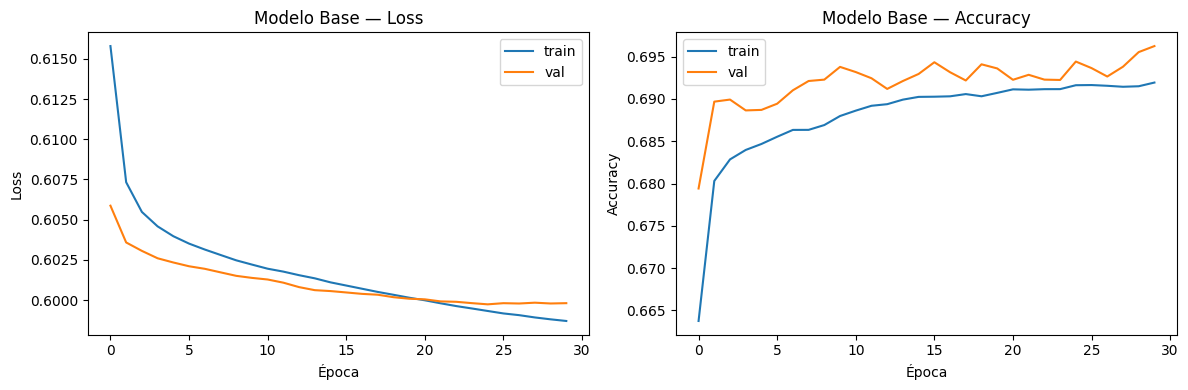

In [11]:
# ---- Curvas de convergencia (reutilizable para Base y Fair) ----
import matplotlib.pyplot as plt

def plot_convergencia(hist, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history['loss'],     label='train')
    ax[0].plot(hist.history['val_loss'], label='val')
    ax[0].set_title(f'{titulo} — Loss'); ax[0].set_xlabel('Época'); ax[0].set_ylabel('Loss'); ax[0].legend()
    ax[1].plot(hist.history['accuracy'],     label='train')
    ax[1].plot(hist.history['val_accuracy'], label='val')
    ax[1].set_title(f'{titulo} — Accuracy'); ax[1].set_xlabel('Época'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_convergencia(hist_base, 'Modelo Base')

### 1.4. Modelo Fair (Fair Loss con λ=1)

Mismo modelo entrenado con la Fair Loss en $\lambda=1$ y sobre la vista **sin género** (`X_fair`, 10 variables): la variable sensible no se proporciona como entrada y solo interviene en la penalización por dependencia. El valor $\lambda=1$ se fija como punto representativo del trade-off, donde la penalización reduce sustancialmente la dependencia con un coste mínimo en capacidad predictiva.

Model: "modelo_fair"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step - accuracy: 0.6528 - loss: 0.6390 - val_accuracy: 0.6823 - val_loss: 0.6216
Epoch 2/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.6792 - loss: 0.6238 - val_accuracy: 0.6889 - val_loss: 0.6201
Epoch 3/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step - accuracy: 0.6816 - loss: 0.6222 - val_accuracy: 0.6937 - val_loss: 0.6194
Epoch 4/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step - accuracy: 0.6815 - loss: 0.6211 - val_accuracy: 0.6944 - val_loss: 0.6193
Epoch 5/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step - accuracy: 0.6818 - loss: 0.6207 - val_accuracy: 0.6948 - val_loss: 0.6189
Epoch 6/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step - accuracy: 0.6824 - loss: 0.6202 - val_accuracy: 0.6959 - val_loss: 0.6187
Epoch 7/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step - accuracy: 0.6821 - loss: 0.6199 - val_accuracy: 0.6967 - val_loss: 0.6186
Epoch 8/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.6827 -

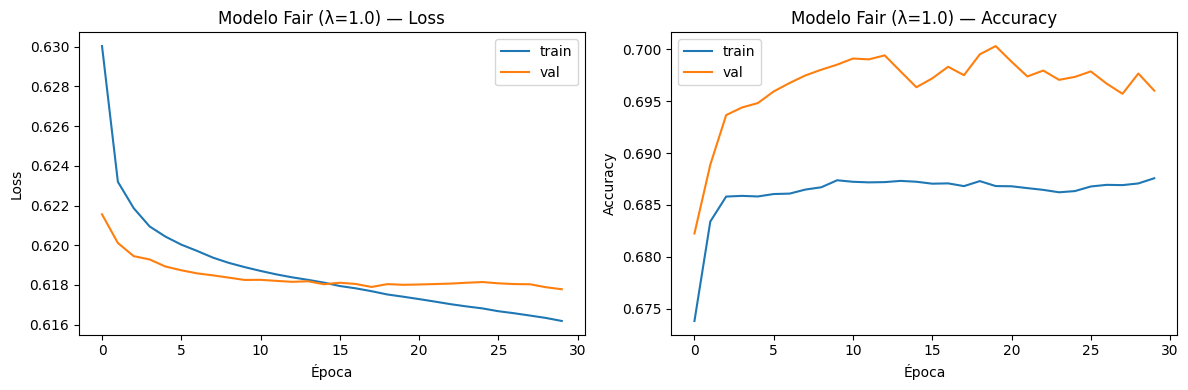

In [12]:
# ---- Modelo Fair: Fair Loss con lambda=1, vista SIN género ----
LAMBDA_FAIR = 1.0

model_fair = construir_mlp(X_fair_tr.shape[1], 'modelo_fair')
model_fair.compile(optimizer='adam',
                   loss=FairLoss(lam=LAMBDA_FAIR, w0=W0, w1=W1),
                   metrics=[AccExt(name='accuracy')])
model_fair.summary()

hist_fair = model_fair.fit(
    X_fair_tr, y_tr_ext,
    validation_data=(X_fair_va, y_va_ext),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)

plot_convergencia(hist_fair, f'Modelo Fair (λ={LAMBDA_FAIR})')

### 1.5. Comparativa Base vs Fair en test

Resultados de ambos modelos sobre el **mismo** conjunto de test. La columna de dependencia $|\rho(\hat{y}, s)|$ cuantifica la (in)justicia —menor es más justo—; el AUC-ROC mide la capacidad predictiva independiente del umbral y el AUC-PR la calidad de detección sobre la clase minoritaria. La accuracy y el recall se reportan al umbral 0,5.

In [13]:
# ---- Comparativa Base vs Fair en test ----
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             recall_score, accuracy_score)
from scipy.stats import pearsonr

def evaluar(model, X_te, nombre):
    p = model.predict(X_te, verbose=0).flatten()
    pred = (p >= 0.5).astype(int)
    return {
        'Modelo': nombre,
        'accuracy': accuracy_score(y_te, pred),
        'AUC-ROC': roc_auc_score(y_te, p),
        'AUC-PR': average_precision_score(y_te, p),
        'recall': recall_score(y_te, pred),
        '|corr(yhat,s)|': abs(pearsonr(p, s_te)[0]),
    }

tabla = pd.DataFrame([
    evaluar(model_base, X_base_te, 'Base (lambda=0)'),
    evaluar(model_fair, X_fair_te, f'Fair (lambda={LAMBDA_FAIR})'),
]).set_index('Modelo').round(4)

dep_base, dep_fair = tabla.iloc[0]['|corr(yhat,s)|'], tabla.iloc[1]['|corr(yhat,s)|']
auc_base, auc_fair = tabla.iloc[0]['AUC-ROC'], tabla.iloc[1]['AUC-ROC']
print(tabla.to_string())
print(f'\nReduccion de dependencia: {dep_base:.4f} -> {dep_fair:.4f} '
      f'({100*(1-dep_fair/dep_base):.1f}% menos)')
print(f'Coste en AUC-ROC: {auc_base:.4f} -> {auc_fair:.4f} (delta {auc_fair-auc_base:+.4f})')

tabla

                   accuracy  AUC-ROC  AUC-PR  recall  |corr(yhat,s)|
Modelo                                                              
Base (lambda=0)      0.6984   0.7407  0.2224  0.6600          0.2352
Fair (lambda=1.0)    0.6985   0.7338  0.2175  0.6397          0.0577

Reduccion de dependencia: 0.2352 -> 0.0577 (75.5% menos)
Coste en AUC-ROC: 0.7407 -> 0.7338 (delta -0.0069)


,accuracy,AUC-ROC,AUC-PR,recall,"|corr(yhat,s)|"
Modelo,,,,,
Base (lambda=0),0.6984,0.7407,0.2224,0.6600,0.2352
Fair (lambda=1.0),0.6985,0.7338,0.2175,0.6397,0.0577


## 2. Incertidumbre

Se estima la incertidumbre de cada predicción del modelo Fair mediante un segundo modelo (*error-predictor*) que aprende a predecir el error cuadrático $e^2 = (\hat{y} - y)^2$ de la red de clasificación. La salida del error-predictor es la **varianza estimada** de la predicción.

El error-predictor recibe como entrada las features junto con la probabilidad predicha $\hat{y}$, de forma que puede modular la incertidumbre en función tanto del perfil como de la confianza de la predicción. Su salida usa activación ReLU para garantizar una varianza no negativa.

In [14]:
# ---- 2.1. Target (e^2) e input extendido [features, yhat] ----
# Predicciones del modelo Fair sobre cada partición.
p_fair_tr = model_fair.predict(X_fair_tr, verbose=0).flatten()
p_fair_va = model_fair.predict(X_fair_va, verbose=0).flatten()
p_fair_te = model_fair.predict(X_fair_te, verbose=0).flatten()

# Target del error-predictor: error cuadratico (estima la varianza de la prediccion).
e2_tr = (p_fair_tr - y_tr) ** 2
e2_va = (p_fair_va - y_va) ** 2

# Input extendido: features + probabilidad predicha como columna adicional.
Xe_tr = np.column_stack([X_fair_tr, p_fair_tr]).astype('float32')
Xe_va = np.column_stack([X_fair_va, p_fair_va]).astype('float32')
Xe_te = np.column_stack([X_fair_te, p_fair_te]).astype('float32')
print('Shape input extendido (train):', Xe_tr.shape)

Shape input extendido (train): (196796, 11)


### 2.2. Error-predictor

Red de regresión `Dense(10, sigmoid) → Dense(1, ReLU)`, entrenada con MSE para predecir $e^2$. La salida ReLU restringe la predicción a valores no negativos, coherente con una varianza.

Model: "error_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 370us/step - loss: 0.0190 - mae: 0.0924 - val_loss: 0.0118 - val_mae: 0.0660
Epoch 2/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step - loss: 0.0113 - mae: 0.0614 - val_loss: 0.0110 - val_mae: 0.0588
Epoch 3/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 330us/step - loss: 0.0106 - mae: 0.0546 - val_loss: 0.0108 - val_mae: 0.0567
Epoch 4/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 334us/step - loss: 0.0104 - mae: 0.0518 - val_loss: 0.0107 - val_mae: 0.0555
Epoch 5/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step - loss: 0.0104 - mae: 0.0506 - val_loss: 0.0107 - val_mae: 0.0548
Epoch 6/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - loss: 0.0103 - mae: 0.0499 - val_loss: 0.0107 - val_mae: 0.0545
Epoch 7/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step - loss: 0.0103 - mae: 0.0494 - val_loss: 0.0107 - val_mae: 0.0543
Epoch 8/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1s 330us/step - loss: 0.0103 - mae: 0.0491 - val_loss: 0.0106 - val_mae: 0.0540
Epoch 9/30
1538/1538 ━━━

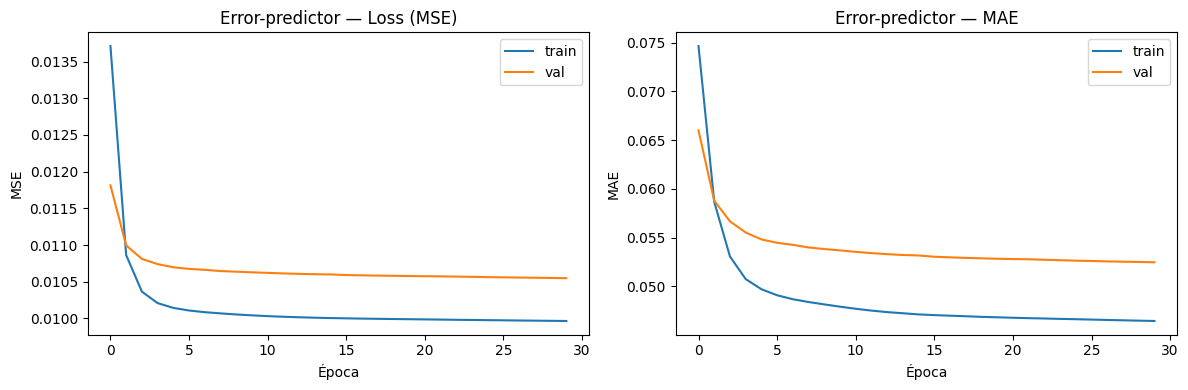

In [15]:
# ---- Error-predictor: entrenamiento ----
keras.utils.set_random_seed(SEED)
error_predictor = keras.Sequential([
    keras.layers.Input(shape=(Xe_tr.shape[1],)),
    keras.layers.Dense(10, activation='sigmoid'),
    keras.layers.Dense(1,  activation='relu')      # varianza estimada (>= 0)
], name='error_predictor')

error_predictor.compile(optimizer='adam', loss='mse', metrics=['mae'])
error_predictor.summary()

hist_unc = error_predictor.fit(
    Xe_tr, e2_tr,
    validation_data=(Xe_va, e2_va),
    epochs=30, batch_size=128, verbose=1
)

# Curva de convergencia del error-predictor.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_unc.history['loss'], label='train'); ax[0].plot(hist_unc.history['val_loss'], label='val')
ax[0].set_title('Error-predictor — Loss (MSE)'); ax[0].set_xlabel('Época'); ax[0].set_ylabel('MSE'); ax[0].legend()
ax[1].plot(hist_unc.history['mae'], label='train'); ax[1].plot(hist_unc.history['val_mae'], label='val')
ax[1].set_title('Error-predictor — MAE'); ax[1].set_xlabel('Época'); ax[1].set_ylabel('MAE'); ax[1].legend()
plt.tight_layout(); plt.show()

# Incertidumbre estimada en test.
incertidumbre_te = error_predictor.predict(Xe_te, verbose=0).flatten()

### 2.3. Distribución de la incertidumbre: buen pagador vs mal pagador

Comparación de la incertidumbre estimada entre las dos clases reales del conjunto de test.

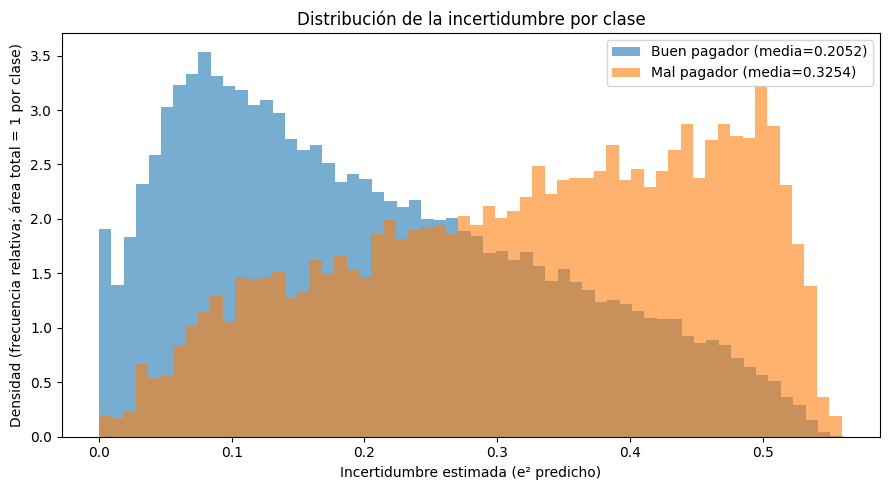

Incertidumbre media | Buen pagador: 0.20517 | Mal pagador: 0.32543


In [18]:
# ---- Grafico 1: incertidumbre por clase real ----
unc_buen = incertidumbre_te[y_te == 0]
unc_mal  = incertidumbre_te[y_te == 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(unc_buen, bins=60, alpha=0.6, density=True, label=f'Buen pagador (media={unc_buen.mean():.4f})')
ax.hist(unc_mal,  bins=60, alpha=0.6, density=True, label=f'Mal pagador (media={unc_mal.mean():.4f})')
# density=True -> el eje Y es densidad de probabilidad (el area de cada clase suma 1),
# necesario para comparar dos clases de tamaño muy distinto (92% vs 8%).
ax.set_xlabel('Incertidumbre estimada (e² predicho)')
ax.set_ylabel('Densidad (frecuencia relativa; área total = 1 por clase)')
ax.set_title('Distribución de la incertidumbre por clase'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Incertidumbre media | Buen pagador: {unc_buen.mean():.5f} | Mal pagador: {unc_mal.mean():.5f}')

### 2.4. Incertidumbre frente a la calidad de las fuentes externas

Se agrupa el conjunto de test por número de fuentes `EXT_SOURCE` imputadas (0 a 3), usando los flags de missingness, y se compara la incertidumbre estimada de cada grupo. Una incertidumbre creciente con el número de fuentes imputadas indicaría que el modelo es menos fiable en perfiles con peor calidad de información externa.

/var/folders/0v/sc3tfmjd6cg4c6dnrw_7_lfr0000gn/T/ipykernel_1168/3261696607.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(datos_box, labels=[str(k) for k in grupos], showfliers=False)


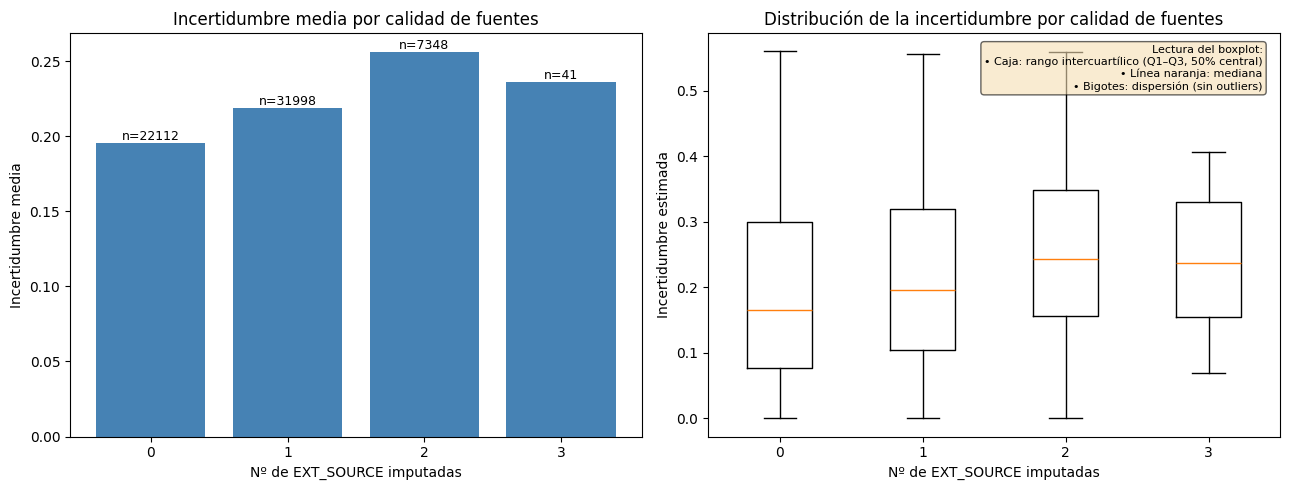

Incertidumbre media por nº de EXT_SOURCE imputadas:
  0 imputadas (n= 22112): 0.19578
  1 imputadas (n= 31998): 0.21862
  2 imputadas (n=  7348): 0.25598
  3 imputadas (n=    41): 0.23583


In [19]:
# ---- Grafico 2: incertidumbre vs nº de EXT_SOURCE imputadas ----
n_imputadas = df_fair.loc[idx_te, FLAG_COLS].sum(axis=1).values   # 0..3 por individuo

grupos = [0, 1, 2, 3]
medias = [incertidumbre_te[n_imputadas == k].mean() if (n_imputadas == k).any() else np.nan
          for k in grupos]
conteos = [int((n_imputadas == k).sum()) for k in grupos]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Barras: incertidumbre media por grupo
ax[0].bar([str(k) for k in grupos], medias, color='steelblue')
for i, (m, n) in enumerate(zip(medias, conteos)):
    if not np.isnan(m): ax[0].text(i, m, f'n={n}', ha='center', va='bottom', fontsize=9)
ax[0].set_xlabel('Nº de EXT_SOURCE imputadas'); ax[0].set_ylabel('Incertidumbre media')
ax[0].set_title('Incertidumbre media por calidad de fuentes')
# Boxplot: distribución por grupo
datos_box = [incertidumbre_te[n_imputadas == k] for k in grupos]
ax[1].boxplot(datos_box, labels=[str(k) for k in grupos], showfliers=False)
ax[1].set_xlabel('Nº de EXT_SOURCE imputadas'); ax[1].set_ylabel('Incertidumbre estimada')
ax[1].set_title('Distribución de la incertidumbre por calidad de fuentes')
# Recuadro explicativo de los elementos del boxplot
texto = ('Lectura del boxplot:\n'
         '• Caja: rango intercuartílico (Q1–Q3, 50% central)\n'
         '• Línea naranja: mediana\n'
         '• Bigotes: dispersión (sin outliers)')
ax[1].text(0.97, 0.97, texto, transform=ax[1].transAxes, fontsize=8,
           va='top', ha='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
plt.tight_layout(); plt.show()

print('Incertidumbre media por nº de EXT_SOURCE imputadas:')
for k, m, n in zip(grupos, medias, conteos):
    print(f'  {k} imputadas (n={n:6d}): {m:.5f}')